## Prerequisites
- Complete the [One-Time Setup](https://mwvgroup.github.io/pittgoogle-client/one-time-setup/index.html), specifically:
     - Install the pittgoogle-client package
     - Setup authentication to a Google Cloud project
     - Set environment variables
     - Enable the BigQuery API
     - You can skip the command-line tools

In [1]:
import pittgoogle

# define the Pitt-Google Alert Broker's GCP project name
pgb_project = "pitt-alert-broker"

%matplotlib widget
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
import numpy as np
import math
import pickle
from pathlib import Path
import os

import mwdust
# Initialize the 2D SFD dust map
sfdMap = mwdust.SFD(filter='E(B-V)')

from astropy.coordinates import SkyCoord
from astropy.stats import sigma_clip

from itertools import compress

In [2]:
# The LSST bands, wavelength in microns from https://lsstcam.lsst.io/
WL = {'u': 0.3724, 'g': 0.4807, 'r': 0.6221, 'i': 0.7559, 'z': 0.8680, 'y': 0.9753}

From Lasiar Examples

These coefficients are for the extinction correction. 
For the g-filter, for example, an E(B-V) value of 0.5 
would increase the g magnitude number by 0.5*3.237 = 1.618 mags,
equivalently decrease the flux by a factor of 10^(1.618/2.5) = 4.43.

These colour corrections are from Table 6 of 
[Schlafly and Finkbeiner](https://iopscience.iop.org/article/10.1088/0004-637X/737/2/103) with RV=3.1

In [3]:
# Multiplier for EBV for magnitude correction
EXTCOEF   = {'u': 4.145, 'g': 3.237, 'r': 2.273, 'i': 1.684, 'z': 1.323, 'y': 1.088}

In [4]:
def scaledBlackbody(wl, T, scale):
    hck = 14.387
    q = np.exp(hck/(wl*T))
    return scale * np.power(wl, -3.0) / (q - 1)

# dustFluxErr would be the same function as dustFlux since the dustFlux is effectively multiplying flux by a constant
def dustFlux(flux, band, ebv):
    return flux*math.pow(10, ebv*EXTCOEF[band]/2.5)

### Plot the light curve and temperatures

In [5]:
def plot(objID, objList, pairTemp, fitTemp, window):
    color = {'u':"#9900cc", 'g':"#3366ff", 'r':"#33cc33", 'i':"#ffcc00", 'z':"#ff0000", 'y':"#cc6600"}
    fig, (ax1, ax2, ax3) = plt.subplots(3, height_ratios=[2,1,2], figsize=(8,12), layout = 'constrained')
    # ax1.set_yscale('log')

    bars1 = []
    fbars1 = []
    for band in color.keys():
        mask = (objList.band == band) & (~objList.isForced)
        fmask = (objList.band == band) & (objList.isForced)
        mjd = objList.loc[mask, 'midpointMjdTai']
        flux = objList.loc[mask, 'psfFlux']
        fluxErr = objList.loc[mask, 'psfFluxErr']
        
        fmjd = objList.loc[fmask, 'midpointMjdTai']
        fflux = objList.loc[fmask, 'psfFlux']
        ffluxErr = objList.loc[fmask, 'psfFluxErr']
                    
        # plot the sources
        bars1.append(ax1.errorbar(mjd, flux, yerr=fluxErr, marker='o', markeredgewidth=0,
                                  color=color[band], linestyle = 'None', label=band))
        
        fbars1.append(ax1.errorbar(fmjd, fflux, yerr=ffluxErr, marker='X', markeredgewidth=0,
                                   color=color[band], linestyle = 'None', label=f'forced {band}'))
        
    bars1 = bars1 + fbars1
        
    fig.suptitle(f'Lightcuve of {objID}')
    ax1.set_xlabel('MJD')
    ax1.set_ylabel('Flux (nJy)')

    leg1 = ax1.legend(handles=bars1, ncols=2, handlelength=0.5, handletextpad=0.5)
    
    for i in range(len(pairTemp['temp'])):
        ax2.plot(pairTemp['mjd'][i], pairTemp['temp'][i],
                 marker = 'o', markeredgewidth=0, fillstyle='left',
                 markerfacecolor=color[pairTemp['filter1'][i]], markerfacecoloralt=color[pairTemp['filter2'][i]],
                 zorder=1)
        
    ax2.errorbar(fitTemp['mjd'], fitTemp['temp'], yerr=fitTemp['tempErr'],
                 marker = '*', linestyle = 'None', color = 'black', zorder=10, label='fitTemp')
    
    ax2.sharex(ax1)

    ax2.set_title('Calculated Pair and Fit Temperature of ' + str(objID))
    ax2.set_xlabel("MJD")
    ax2.set_ylabel("Temperature (kK)")

    ax2.legend(handlelength=0.5, handletextpad=0.5)

    cmap = plt.colormaps['inferno']
    blackbodyColors = cmap(np.linspace(0, 1, len(fitTemp['temp'])))
    
    x = np.linspace(0, 1.5, 51)[1:]
    markers = ['o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'H', 'D', 'd', 'P', 'X']

    bars3 = []
    lines3 = []
    for i in range(len(fitTemp['temp'])):
        bars3.append(ax3.errorbar(fitTemp['wavelengths'][i], fitTemp['fluxs'][i], yerr=fitTemp['fluxErrs'][i],
                                    marker = markers[i%len(markers)], markeredgewidth=0,
                                    linestyle = 'None', color = blackbodyColors[i],
                                    label = f'{fitTemp['temp'][i]:.2f} kK at {fitTemp['mjd'][i]}'))
        y = scaledBlackbody(x, fitTemp['temp'][i], fitTemp['scale'][i])
        line, = ax3.plot(x, y, color = blackbodyColors[i])
        lines3.append(line)

    # Make the lines inviable if clicked on in the legend. Adapted from https://matplotlib.org/stable/gallery/event_handling/legend_picking.html
    leg3 = fig.legend(handles=bars3, loc='outside lower center', ncols=5, mode='expand', handlelength=0.5, handletextpad=0.5) 

    mapLegendToAx = {}  # Will map legend lines to original lines.

    pickRadius = 5  # Points (Pt). How close the click needs to be to trigger an event.

    for legendLine, legendText, axBar in zip(leg1.legend_handles, leg1.get_texts(), bars1):
        legendLine.set_picker(pickRadius) # Enable picking on the legend line.
        legendText.set_picker(pickRadius) # Enable picking on the legend text.
        mapLegendToAx[legendLine] = {'plot': 1, 'bar': axBar, 'text': legendText}
        mapLegendToAx[legendText] = {'plot': 1, 'bar': axBar, 'text': legendText}

    for legendLine, legendText, axBar, axLine in zip(leg3.legend_handles, leg3.get_texts(), bars3, lines3):
        legendLine.set_picker(pickRadius) # Enable picking on the legend line.
        legendText.set_picker(pickRadius) # Enable picking on the legend text.
        mapLegendToAx[legendLine] = {'plot': 3, 'bar': axBar, 'line': axLine, 'text': legendText}
        mapLegendToAx[legendText] = {'plot': 3, 'bar': axBar, 'line': axLine, 'text': legendText}
    
    def on_pick(event):
        # On the pick event, find the original line corresponding to the legend
        # proxy line, and toggle its visibility.
        clickedArtist = event.artist

        # Do nothing if the source of the event is not a legend line.
        if clickedArtist not in mapLegendToAx:
            return
        
        clickedOn = mapLegendToAx[clickedArtist]
        if event.mouseevent.key == 'shift':
            for key in mapLegendToAx:
                notClicked = mapLegendToAx[key]
                if clickedOn['plot'] == notClicked['plot']:
                    if notClicked['plot'] == 3:
                        notClicked['line'].set_visible(False)

                    notClicked['bar'][0].set_visible(False)
                    for bar in notClicked['bar'][1] + notClicked['bar'][2]:
                        bar.set_visible(False)

                    # Change the alpha on the text in the legend, so we can see what lines
                    # have been toggled.
                    notClicked['text'].set_alpha(0.2)
                    
            if clickedOn['plot'] == 3:
                clickedOn['line'].set_visible(True)

            clickedOn['bar'][0].set_visible(True)
            for bar in clickedOn['bar'][1] + clickedOn['bar'][2]:
                bar.set_visible(True)

            # Change the alpha on the text in the legend, so we can see what lines
            # have been toggled.
            clickedOn['text'].set_alpha(1)
        else:
            visible = not clickedOn['bar'][0].get_visible()

            if clickedOn['plot'] == 3:
                clickedOn['line'].set_visible(visible)

            clickedOn['bar'][0].set_visible(visible)
            for bar in clickedOn['bar'][1] + clickedOn['bar'][2]:
                bar.set_visible(visible)

            # Change the alpha on the text in the legend, so we can see what lines
            # have been toggled.            
            clickedOn['text'].set_alpha(1.0 if visible else 0.2)

        fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', on_pick)

    ax3.sharey(ax1)

    ax3.set_title(f'Blackbody Fit for Each Night with Rolling Window of {window} Days')
    ax3.set_ylabel('Flux (nJy)')
    ax3.set_xlabel(r'Wavelength ($\mu$m)')

    ax3.margins(x=0)

    # add labels for each band in the last plot
    ax3.set_xticks(list(tick for tick in WL.values()), list(f'\n{tick}' for tick in WL.keys()), minor = True)

    plt.show()

## Fit Temperature
This method of finding temperature uses the fact that LSST revisits sites in multiple filters each night. This allows fitting a black body curve to the flux data. This results in a temperature and scaling factor for each night.

In [6]:
def weightedMean3Sigma(fluxs, fluxErrs, sqrtAvgCount):
    
    maskedFluxs = sigma_clip(fluxs, sigma=3, cenfunc='median')

    if maskedFluxs.count() == 0:
        return None, None
    
    error = np.ma.std(maskedFluxs) * (sqrtAvgCount/np.sqrt(maskedFluxs.count()))

    # if std = 0 for example if maskedFluxs only has one element or if all elements are the same
    # use the fluxErrs instead to keep the fit function happy
    error = error if error > 0 else np.average(list(compress(fluxErrs, ~maskedFluxs.mask))) * sqrtAvgCount

    return np.ma.average(maskedFluxs, weights=np.pow(fluxErrs, -2)), error

def calculateFitTemp(objList, ebv, window):
    start = objList.midpointMjdTai[0]
    end = objList.midpointMjdTai.iloc[-1]

    output = {'temp': [], 'tempErr': [], 'scale': [], 'scaleErr': [], 'mjd': [],
              'wavelengths': [], 'fluxs': [], 'fluxErrs': []}
    
    i = 0
    start = 0
    # The addition of 0.3 to each time will alow data taken shortly before an integer MJD (8:00PM in Chile)
    # to be added to the rest of the data taken on the same night rather than to the previous night
    mjdOffset = 0.3
    for mjd in range(math.floor(start + mjdOffset), math.ceil(end + mjdOffset)):
        flux = {key: [] for key in WL}
        fluxErr = {key: [] for key in WL}
        bands = set()
        i = start+1
        while i < len(objList) and math.floor(objList.midpointMjdTai[i] + mjdOffset) <= mjd + window - 1:
            if math.floor(objList.midpointMjdTai[i] + mjdOffset) == mjd:
                start = i
            band = objList.band[i]
            bands.add(band)
            flux[band].append(dustFlux(objList.psfFlux[i], band, ebv))
            fluxErr[band].append(dustFlux(objList.psfFluxErr[i], band, ebv))
            i+=1
        if len(bands) >= 3: # ensure that each fit has three filters, two works but gives inconstant results
            fluxMean = []
            fluxStd = []
            wavelength = []

            # modify the std by a factor of sqrt(average count)/sqrt(count in this filter)
            # this modification should tell the fitting function to pay more attention to filters with more points
            sqrtAvgCount = np.sqrt(np.sum(list(map(len, flux))) / len(bands))
            for band in flux:
                if len(flux[band]) > 0:
                    fMean, fStd = weightedMean3Sigma(flux[band], fluxErr[band], sqrtAvgCount)
                    if fMean == None:
                        break
                    fluxMean.append(fMean)
                    fluxStd.append(fStd)
                    wavelength.append(WL[band])
            try:
                fit = curve_fit(scaledBlackbody, wavelength, fluxMean, [12, 1], sigma=fluxStd, absolute_sigma=True)
                output['temp'].append(fit[0][0])
                output['scale'].append(fit[0][1])
                
                error = np.sqrt(np.diag(fit[1]))
                output['tempErr'].append(error[0])
                output['scaleErr'].append(error[1])

                output['mjd'].append(mjd)
                
                output['wavelengths'].append(wavelength)
                output['fluxs'].append(fluxMean)
                output['fluxErrs'].append(fluxStd)
            except:
                print(f'Failed fit with {wavelength} {fluxMean} {fluxStd}')
              
    return output

## Calculate the temperature from pairs of filters taken in a short window
This is not a great method since it gives extremely noisy results and often give significantly different results based on the specific pair of filters used. It is mainly included here to contrast with the fitted temperature which gives significantly better results but operates on a largely similar concept. This function is an improved version of one shown in Lasiar's Examples.

From Lasiar Examples

### Blackbody spectrum
This formula is "per Hertz" to match up with the definition of Jansky.
The number 'hck' is planck * speed of light / boltzmann, with temperature in kilokelvin and wavelength in microns.
There is also the derivative with respect to T so that we can do a Newton solver.
The commented out code shows that the derivative formula is numerically correct.

In [7]:
def blackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) /(q - 1)

def dblackbody(wl, T):
    hck = 14.387
    q = math.exp(hck/(wl*T))
    return math.pow(wl, -3.0) * (hck/(wl*T*T)) * q/((q-1)*(q-1))

From Lasiar Examples

### Newton solver
Given a flux ratio `fluxrat` and two wavelengths `wl1` and `wl2`, we want to solve for the temperature `T`:
```
blackbody(wl1, T)/blackbody(wl2, T) = fluxrat

--> blackbody(wl1, T) - fluxrat* blackbody(wl2, T) = 0
```
However the flux ratio is first modified because of extinction, as the different 
wavelengths are extincted differently. See `EXTCOEF` above. First we make a magnitude change, 
then convert that to a multiplier on the flux ratio.

In [8]:
def solveForTemperature(fluxrat, i1, i2, ebv=0):

    # if i1>i2:
    #     (i1,i2)=(i2,i1)
    #     fluxrat = 1/fluxrat
    
    # modify fluxrat for extinction
    mag_corr = ebv*(EXTCOEF[i1] - EXTCOEF[i2])
    fluxrat_corr = fluxrat*math.pow(10, mag_corr/2.5)
    
    T = 12  # guess 12,000 kelvin
    wl1 = WL[i1]
    wl2 = WL[i2]
    for i in range(50):
        try:
            fr  =  blackbody(wl1, T) - fluxrat_corr* blackbody(wl2, T)
            dfr = dblackbody(wl1, T) - fluxrat_corr*dblackbody(wl2, T)
        except:
            return None
        if dfr == 0:
            print('dfr = 0:', fluxrat, i1, i2, ebv)
            return None
        dT = fr/dfr
        T = T - dT
        if abs(dT) < 0.001: return T # convergence
            
        if T < 0: return None  # not interested in negative temperatures
    return None

### Pair Temperature
This method of finding temperature uses the fact that LSST revisits sites in multiple filters in a short time window. This allows a ratio of fluxes to be found between pairs of filters allowing the Newtonian solver above to estimate a temperature.

In [9]:
def calculatePairTemp(objList, ebv):
    output = {'temp': [], 'mjd': [], 'filter1': [], 'filter2': []}

    # average points of the same filter in a row
    condensedObjList = []
    fluxSum = objList.psfFlux[0]
    MJDSum = objList.midpointMjdTai[0]
    MJDStart = objList.midpointMjdTai[0]
    count = 1

    for i in range(1, len(objList)):
        if objList.band[i] == objList.band[i-1] and objList.midpointMjdTai[i] - objList.midpointMjdTai[i-1] < 0.04:
            fluxSum += objList.psfFlux[i]
            MJDSum += objList.midpointMjdTai[i]
            count += 1
        else:
            condensedObjList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count,
                                     'startMJD': MJDStart, 'endMJD': objList.midpointMjdTai[i-1],
                                     'band': objList.band[i-1]})
            fluxSum = objList.psfFlux[i]
            MJDSum = objList.midpointMjdTai[i]
            MJDStart = objList.midpointMjdTai[i]
            count = 1
    condensedObjList.append({'avgFlux': fluxSum/count, 'avgMJD': MJDSum/count,
                             'startMJD': MJDStart, 'endMJD': objList.midpointMjdTai[i-1],
                             'band': objList.band[i-1]})

    # calculate temperature for all pairs of points that are close enough together regardless of adjacency
    for i in range(0, len(condensedObjList) - 1):
        s1 = condensedObjList[i]
        s2 = condensedObjList[i+1]
        ahead = 1
        while s2['startMJD'] - s1['endMJD'] < 0.04:
            if s1['band'] != s2['band']:
                s = solveForTemperature(s1['avgFlux']/s2['avgFlux'], s1['band'], s2['band'], ebv)
                if s:
                    output['temp'].append(s)
                    output['mjd'].append((s2['startMJD'] + s1['endMJD'])/2)
                    output['filter1'].append(s1['band'])
                    output['filter2'].append(s2['band'])
            ahead+=1
            if i+ahead < len(condensedObjList):
                s2 = condensedObjList[i+ahead]
            else:
                break

    return output

## Plot Temperature
plotTemp plots the light curve of a given object in addition to the calculated pair temperature for each pair of filters and the fitted temperature for each night with observations in different bands.

In [ ]:
def plotTemp(diaObjectId, save=False, update=True, window=3):
    try:
        file_path = Path(f'{os.getenv('OBJECT_CACHE_DIR')}example-objects/object{diaObjectId}.pkl')
    except:
        if (not update) or save:
            raise
        else:
            # ignore the error if we are not using the file path
            pass

    # if it exists and we dont want to update use cashed object list load a saved file
    if (not update) and file_path.is_file():
        with open(file_path, 'rb') as inf: 
            objList = pickle.load(inf)
    else:
        bqclient = pittgoogle.bigquery.Client() # load the BigQuery client
        
        sql_query = f"""
        WITH latest_alert AS (
            SELECT
            alerts.diaObject,
            alerts.diaSource,
            alerts.prvDiaSources,
            alerts.prvDiaForcedSources
            FROM `pitt-alert-broker.lsst.alerts_v10_0` as alerts
            WHERE alerts.diaObject.diaObjectId = {diaObjectId}

            UNION ALL

            SELECT
            alerts.diaObject,
            alerts.diaSource,
            alerts.prvDiaSources,
            alerts.prvDiaForcedSources
            FROM `pitt-alert-broker.lsst.alerts_v11_0` as alerts
            WHERE alerts.diaObject.diaObjectId = {diaObjectId}

            ORDER BY diaSource.midpointMjdTai DESC
            LIMIT 1
        )

        SELECT
        diaObject.diaObjectId,
        diaObject.ra,
        diaObject.dec,
        diaSource.midpointMjdTai,
        diaSource.psfFlux,
        diaSource.psfFluxErr,
        diaSource.band,
        FALSE AS isForced
        FROM latest_alert

        UNION ALL

        SELECT
        diaObject.diaObjectId,
        diaObject.ra,
        diaObject.dec,
        prv.midpointMjdTai,
        prv.psfFlux,
        prv.psfFluxErr,
        prv.band,
        FALSE AS isForced
        FROM latest_alert,
        UNNEST(prvDiaSources) AS prv

        UNION ALL

        SELECT
        diaObject.diaObjectId,
        diaObject.ra,
        diaObject.dec,
        prvforced.midpointMjdTai,
        prvforced.psfFlux,
        prvforced.psfFluxErr,
        prvforced.band,
        TRUE AS isForced
        FROM latest_alert,
        UNNEST(prvDiaForcedSources) AS prvforced

        ORDER BY midpointMjdTai
        """

        bqclient.query(query=sql_query, dry_run=True)
        objList = bqclient.query(query=sql_query)

        objList.dropna(subset=['midpointMjdTai', 'psfFlux', 'band'], inplace = True)
        objList.fillna(value={'psfFluxErr': np.nanmax(objList.psfFluxErr, initial=0)}, inplace = True)
        objList.reset_index(drop=True, inplace=True)

        if save == True:
            with open(file_path, 'wb') as outf:
                pickle.dump(objList, outf)

    c = SkyCoord(objList.ra[0], objList.dec[0], unit="deg", frame='icrs')

    # The third argument is a distance
    # It seems to have no affect since SFD is 2D not 3D but it is a required field
    # I pass a large distance (100 kpc) in case it matters at some locations
    ebv = sfdMap(c.galactic.l.deg, c.galactic.b.deg, 100)[0]

    print('Object Id:', diaObjectId)

    pairTemp = calculatePairTemp(objList, ebv)

    fitTemp = calculateFitTemp(objList, ebv, window)
    mean = weightedMean3Sigma(fitTemp['temp'], fitTemp['tempErr'], np.sqrt(len(fitTemp['temp'])))
    print(f'Fit Temperature Weighted 3 Sigma Mean: {mean[0]} kK')
    print(f'Fit Temperature Standard Deviation: {mean[1]} kK')
    print(f'Fit Temperature Median: {np.median(fitTemp['temp'])} kK')

    plot(diaObjectId, objList, pairTemp, fitTemp, window)

## Examples
- The plots can be zoomed, paned, saved, etc. using the buttons on the top left
- Curves can be disabled or reenabled by clicking on them in the legend
- All curves but the one clicked on can be disabled by shift clicking

### Example 1 object 170028526486945858
plotTemp takes an objectID and get the required information from the pitt-google broker. It can be configured to save the result of the query and use it for future runs.

Object Id: 170028526486945858
Fit Temperature Weighted 3 Sigma Mean: 9.866151254534872 kK
Fit Temperature Standard Deviation: 1.1683631880802476 kK
Fit Temperature Median: 9.96564845222402 kK


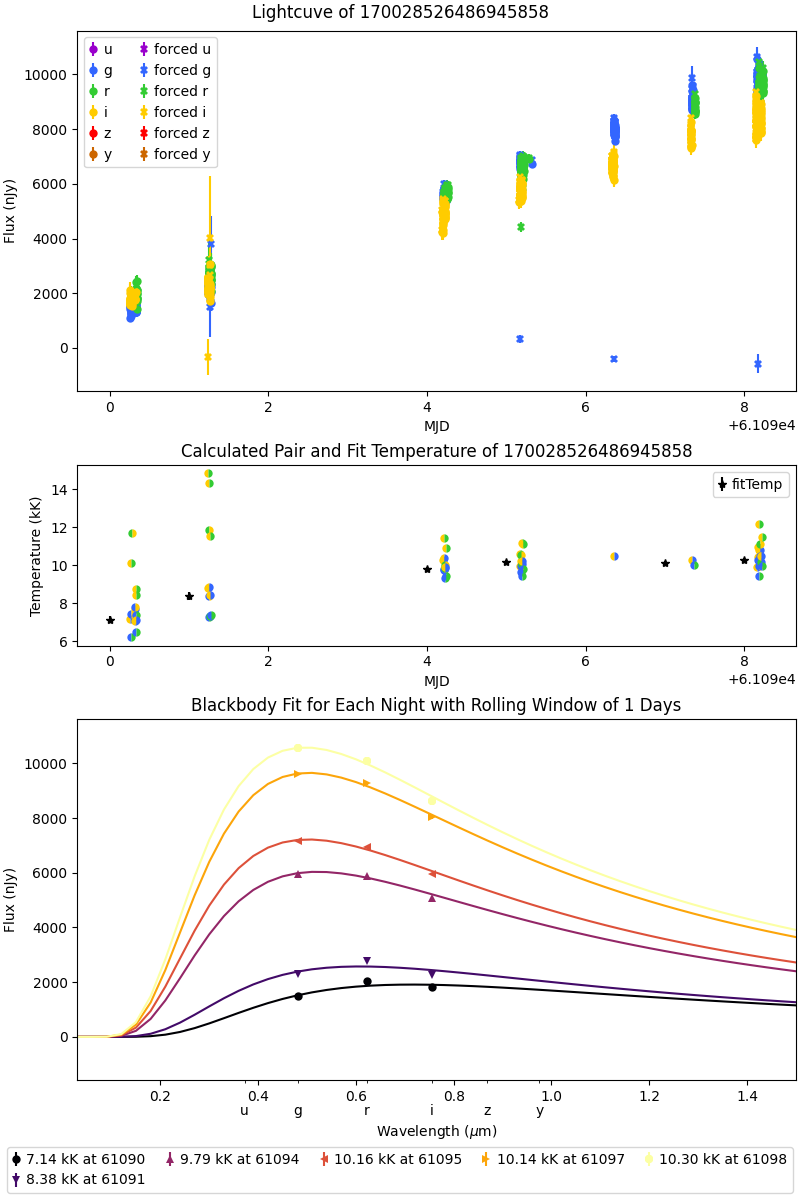

In [11]:
diaObjectId = 170028526486945858
plotTemp(diaObjectId, save=True, update=False, window=1)

### Example 2 object 313853517401423939

Object Id: 313853517401423939
Fit Temperature Weighted 3 Sigma Mean: 7.9507290463743105 kK
Fit Temperature Standard Deviation: 0.7917949349644525 kK
Fit Temperature Median: 8.02275121827196 kK


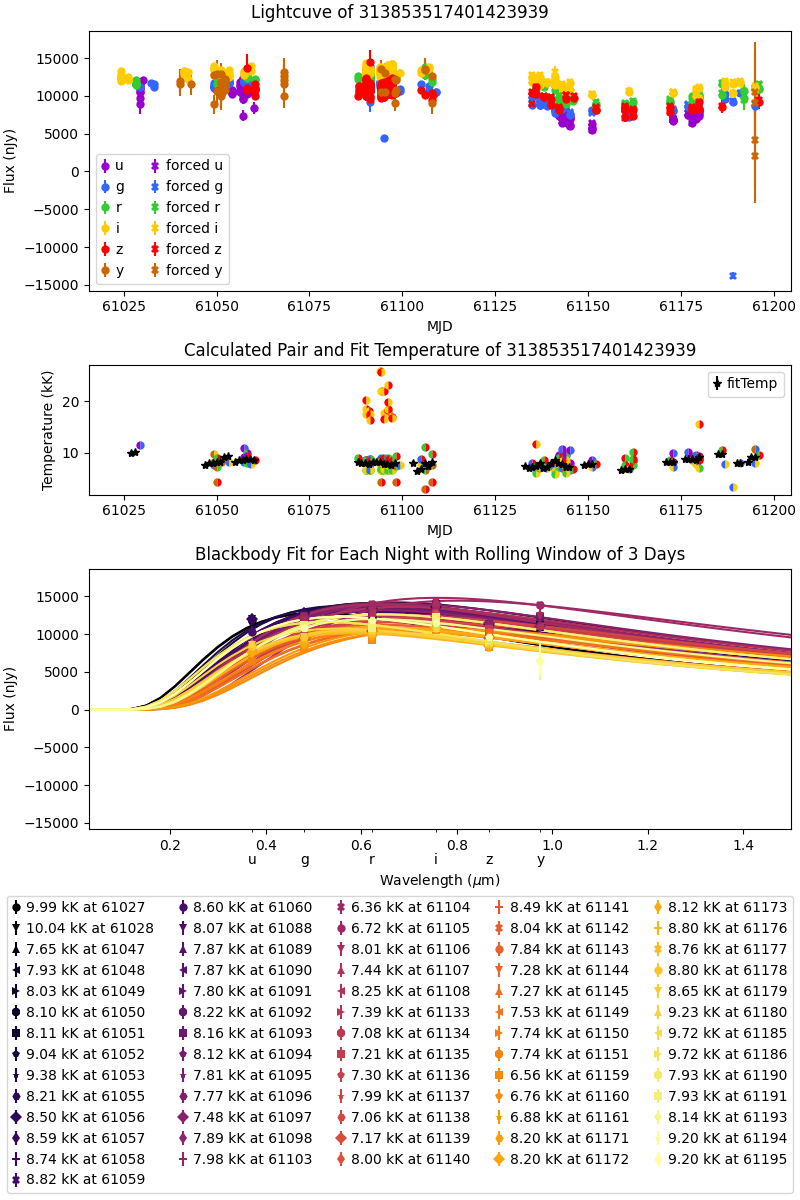

In [13]:
diaObjectId = 313853517401423939
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 3 object 313928194477522960

Object Id: 313928194477522960
Fit Temperature Weighted 3 Sigma Mean: 3.941130032167722 kK
Fit Temperature Standard Deviation: 1.6131088748519402 kK
Fit Temperature Median: 6.359523256783885 kK


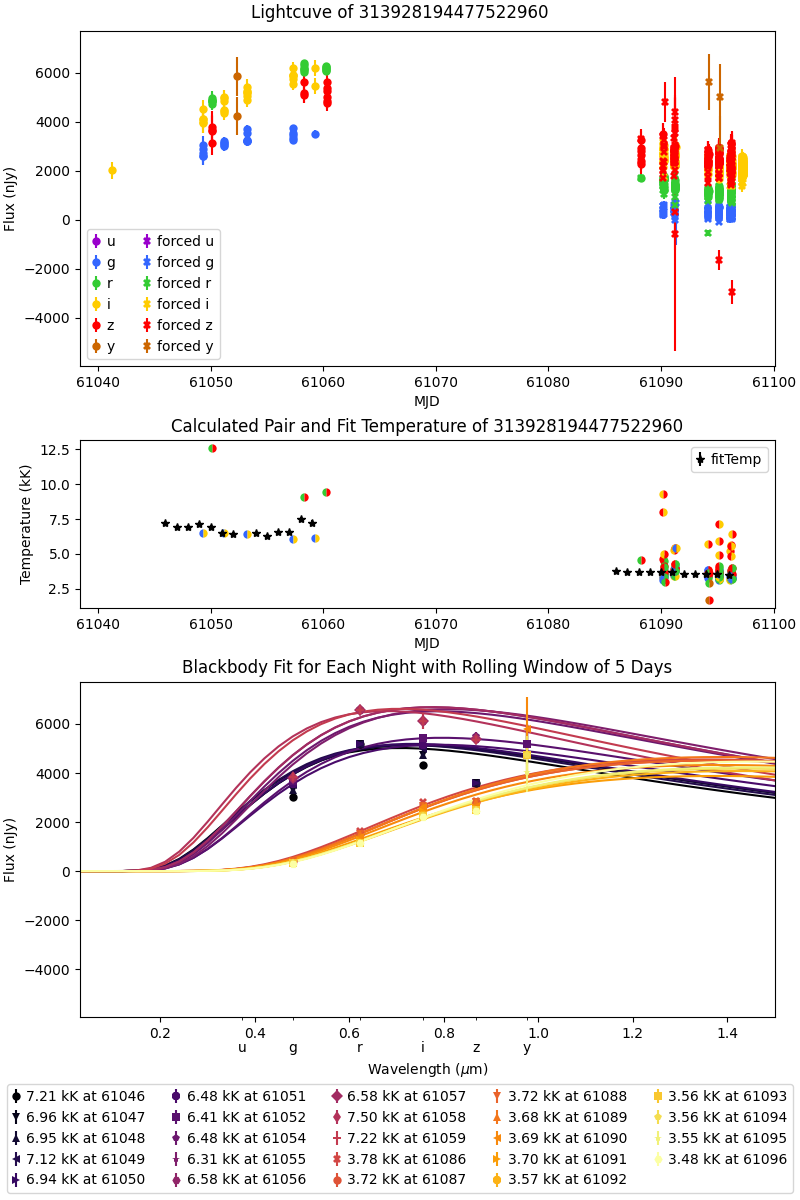

In [14]:
diaObjectId = 313928194477522960
plotTemp(diaObjectId, save=True, update=False, window=5)

### Example 4 object 313853517416628317 compared to GAIA
Gaia DR3 3848359966449030272

Teff    7070 [7039, 7110]	K

Object Id: 313853517416628317
Fit Temperature Weighted 3 Sigma Mean: 7.389686552297429 kK
Fit Temperature Standard Deviation: 1.6850232905094924 kK
Fit Temperature Median: 8.80917000957991 kK


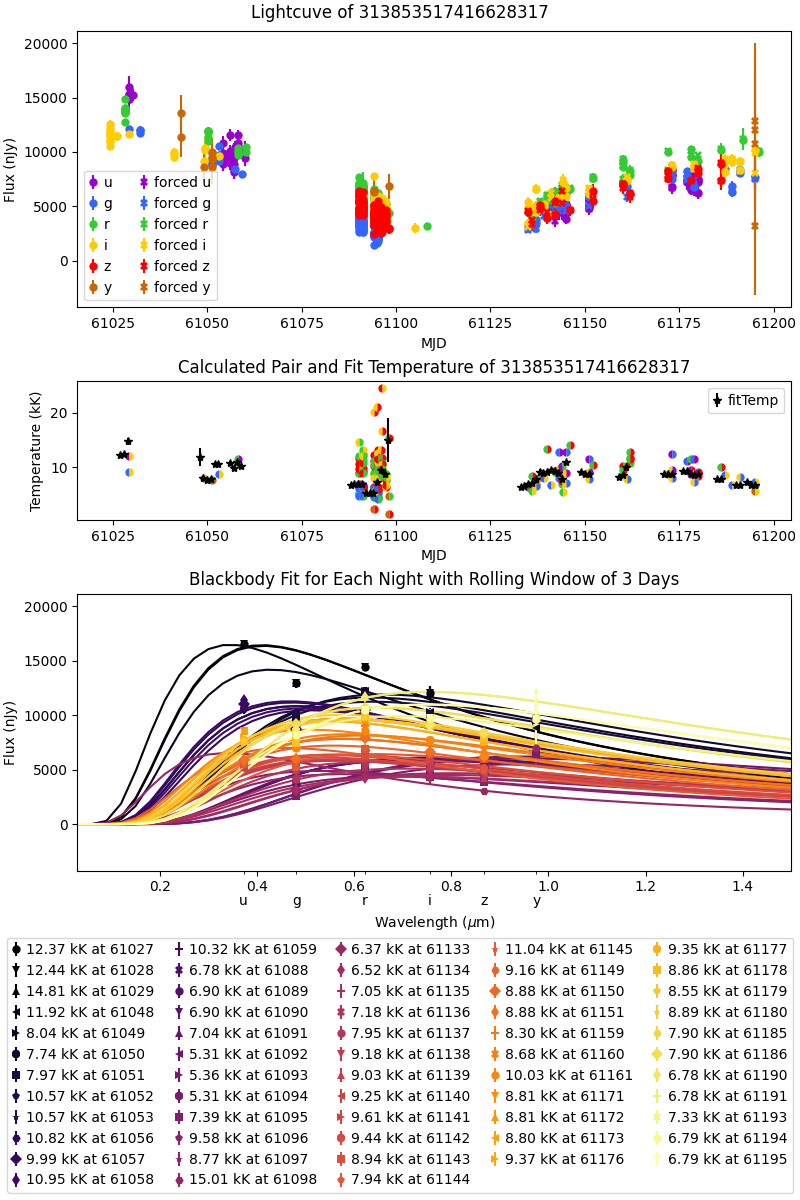

In [15]:
diaObjectId = 313853517416628317
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 5 object 313875415093477395 compared to GAIA
Gaia DR3 3836000768557705344

Teff	6132 [6108, 6153]	K

Object Id: 313875415093477395
Fit Temperature Weighted 3 Sigma Mean: 9.88121768419561 kK
Fit Temperature Standard Deviation: 2.114142525657524 kK
Fit Temperature Median: 10.670509511977805 kK


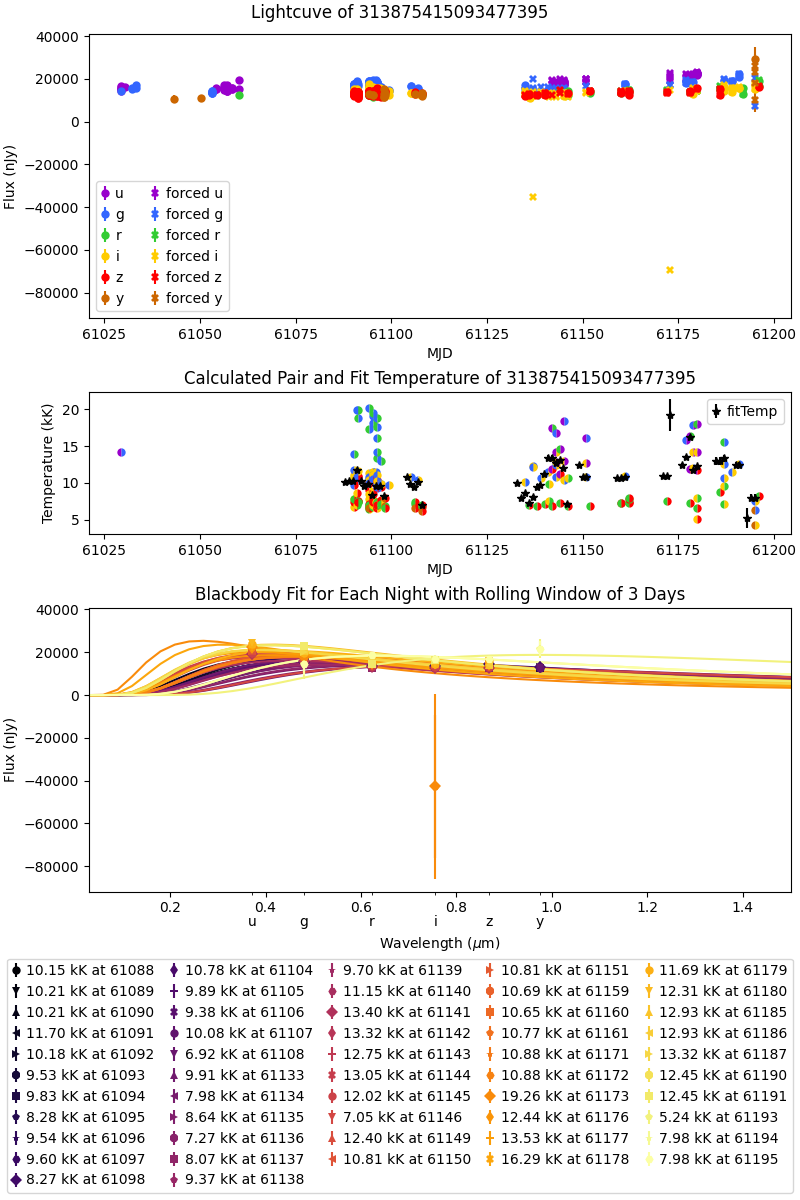

In [28]:
diaObjectId = 313875415093477395
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 6 object 313875415068311567 compared to GAIA
Gaia DR3 3836290318072886656

Teff	6233 [6196, 6263]	K

Object Id: 313875415068311567
Fit Temperature Weighted 3 Sigma Mean: 8.294523801622098 kK
Fit Temperature Standard Deviation: 0.9760133922671098 kK
Fit Temperature Median: 8.530916908721387 kK


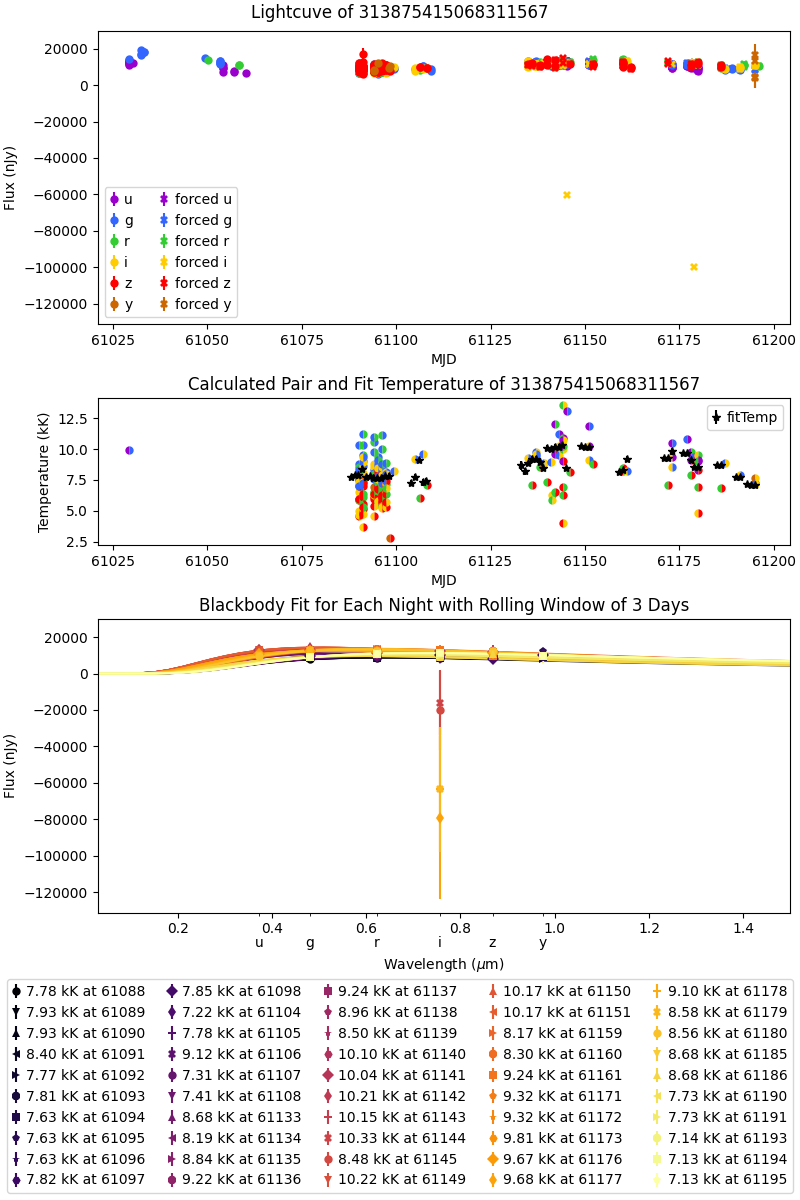

In [17]:
diaObjectId = 313875415068311567
plotTemp(diaObjectId, save=True, update=False, window=3)

### Example 7 object 313893021594157146 compared to GAIA
Gaia DR3 4111834567779557376

Teff	5934 [5874, 6013]	K

Object Id: 313893021594157146
Fit Temperature Weighted 3 Sigma Mean: 2.9361296072803458 kK
Fit Temperature Standard Deviation: 0.2316669818773921 kK
Fit Temperature Median: 3.188793749295863 kK


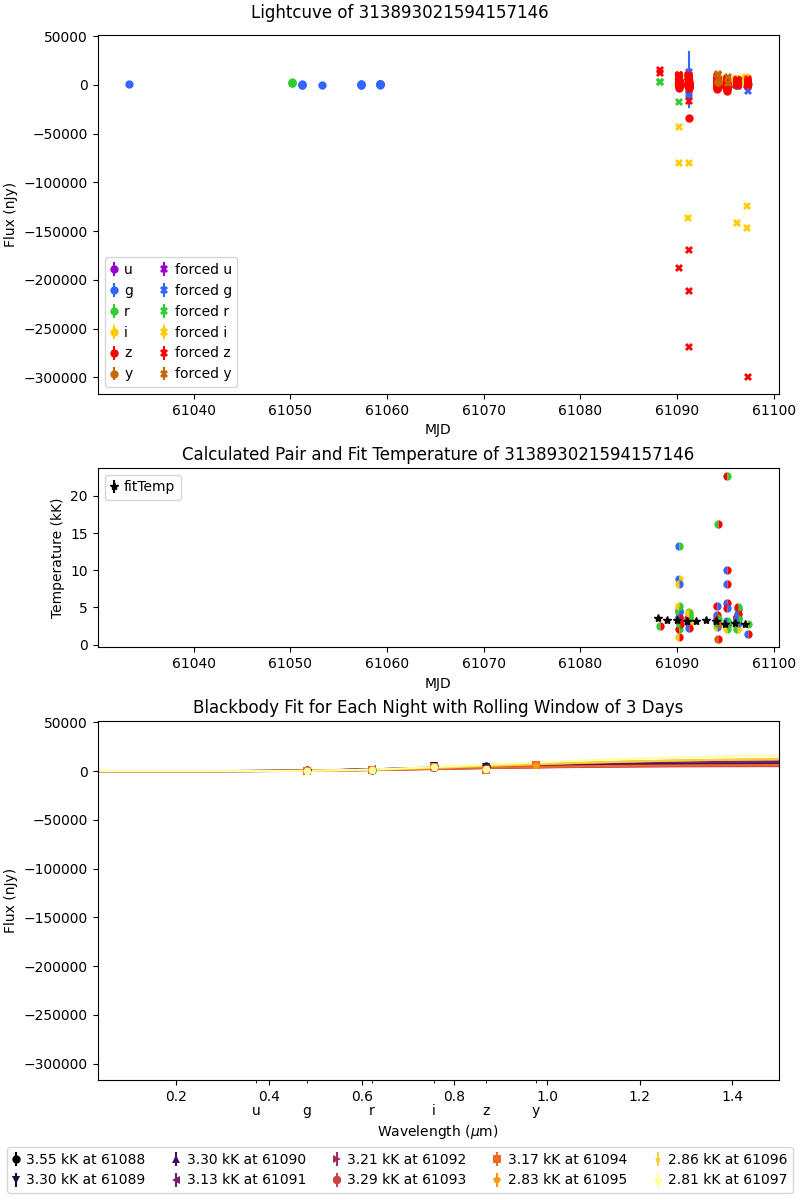

In [ ]:
diaObjectId = 313893021594157146
plotTemp(diaObjectId, save=True, update=False, useScience=True, window=3)

In [23]:
import pandas as pd
pd.set_option('display.max_rows', 500)

In [24]:
alerts_tbl = pittgoogle.bigquery.Table(name="agn", dataset="xmatch_gaia", projectid=pgb_project)
alerts_tbl.schema

,name,type,mode
0,solution_id_var,INTEGER,NULLABLE
1,source_id,INTEGER,NULLABLE
2,fractional_variability_g,FLOAT,NULLABLE
3,structure_function_index,FLOAT,NULLABLE
4,structure_function_index_scatter,FLOAT,NULLABLE
5,qso_variability,FLOAT,NULLABLE
6,non_qso_variability,FLOAT,NULLABLE
7,solution_id_gaia,INTEGER,NULLABLE
8,designation,STRING,NULLABLE
9,random_index,INTEGER,NULLABLE
